In [4]:
# CVIA Lab Week 4 - Code Example 2: Background Subtraction (Image Segmentation) with a Reusable Function
# Author: Min Wang
# Created: 2026/02/26


# Import libraries
import cv2
import numpy as np
import os 
import matplotlib.pyplot as plt

In [5]:
# Let's define our function for computing background subtraction
# This function should have two inputs (an input image and a background image)
# It should return two outputs: the binary mask and the cut-out image. 
# Inside the function, it includes all the processing steps we have discussed in Code Example 1.

def compute_background_subtracted_img(input_img, background_img):

    # Convert to gray
    gray_input = cv2.cvtColor(input_img, cv2.COLOR_BGR2GRAY)
    gray_background = cv2.cvtColor(background_img, cv2.COLOR_BGR2GRAY)

    # Compute difference
    diff_img = cv2.absdiff(gray_input, gray_background)
    # Normalisation
    diff_img = cv2.normalize(diff_img, None, 0, 255,
                             cv2.NORM_MINMAX).astype(np.uint8)

    # Thresholding
    _, binary_mask = cv2.threshold(diff_img, 40, 255,
                                   cv2.THRESH_BINARY)

    # Create structuring element
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))

    # Perform dilation and erosion
    clean_mask = cv2.morphologyEx(
        binary_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    # Apply the binary mask
    mask_3ch = cv2.cvtColor(clean_mask,
                            cv2.COLOR_GRAY2BGR) / 255.0

    cut_out_img = (input_img * mask_3ch).astype(np.uint8)

    return clean_mask, cut_out_img



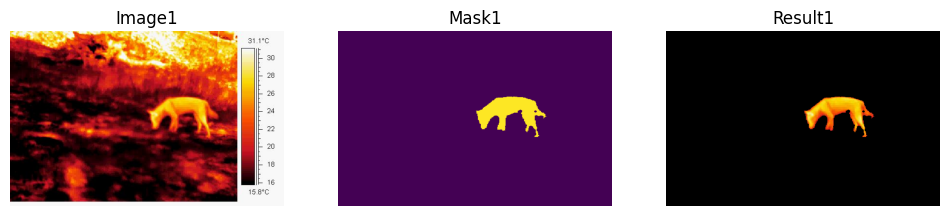

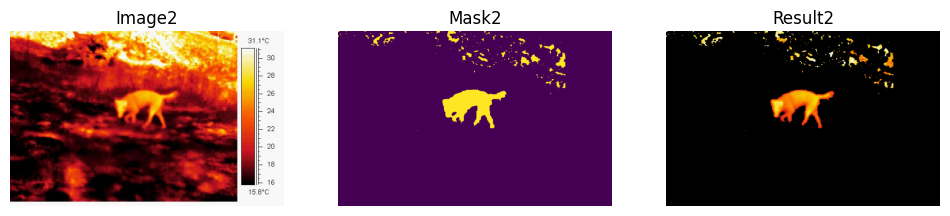

In [7]:
# Now we can use this function for processing an image or multiple frames
# Let’s say we have two frames with dingo, and of course the background image. 
# We can reuse the above function to segment the dingo from the two frames.

background_img = cv2.imread("DINGO3_Background.jpg")
dingo_img1 = cv2.imread("DINGO3_Frame0.jpg")
dingo_img2 = cv2.imread("DINGO3_Frame477.jpg")

background_img = cv2.cvtColor(background_img, cv2.COLOR_BGR2RGB)
dingo_img1 = cv2.cvtColor(dingo_img1, cv2.COLOR_BGR2RGB)
dingo_img2 = cv2.cvtColor(dingo_img2, cv2.COLOR_BGR2RGB)

dingo_images = [dingo_img1, dingo_img2]

for i, img in enumerate(dingo_images):

    mask, result = compute_background_subtracted_img(
        img,
        background_img
    )

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title(f"Image{i+1}")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(mask)
    plt.title(f"Mask{i+1}")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(result)
    plt.title(f"Result{i+1}")
    plt.axis('off')
